# Three-stage SOP-driven SLAM-SIG transposition-domain selection

Candidate domains: SLAM-SIG 24 hr and 72 hr at every GSL
level (0.000, 0.025, ..., 0.475).

**Stage 1.** Hard filter on Area Ratio (AR > 5). For each GSL, build the candidate TD as
the geometric intersection of the 24 hr and 72 hr polygons, compute AR = TD area / basin
area, and discard GSLs with AR <= 5.

**Stage 2.** Meteorological review on the survivors. Build a pixel-level basin envelope
coverage map over the PRISM extent (precip + elevation + dewpoint, with a 5% buffer on each
variable's basin range). Compute Tcap (return-period ceiling) for each survivor. The
meteorologist picks one polygon based on visual judgment plus Tcap.

**Stage 3.** Statistical QA on the selected polygon. Domain-wide climate stats and a
distributional comparison table for the chosen TD vs. the watershed. Descriptive only;
the selection has already been made.

## Imports

In [33]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import geometry_mask
from shapely.geometry import mapping

from scipy.stats import ks_2samp, wasserstein_distance

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx
import matplotlib.font_manager as _fm
import mapclassify

import zipfile
import requests


# Filepaths & Variables

In [34]:
# Target Watershed Domain
WATERSHED_PATH = Path("/workspaces/meteorology-tools/inputs/watershed/allegheny_huc.geojson")
# 24-hour SLAM-SIG Domains
SHP_24 = Path("/workspaces/meteorology-tools/inputs/transposition_domains/TD.AORC.0501.SLAM-SIG.24hr.2024.v1.shp")
# 72-hour SLAM-SIG Domains
SHP_72 = Path("/workspaces/meteorology-tools/inputs/transposition_domains/TD.AORC.0501.SLAM-SIG.72hr.2024.v1.shp")
# PRISM Average 30-year (1991-2020) Annual Precipitation (mm) at 30 arc-seconds (~800 m) resolution
PPT_PATH = Path("/workspaces/meteorology-tools/inputs/prism/annual/prism_ppt_us_30s_2020_avg_30y.tif")
# PRISM Digital Elevation Model (DEM) at 30 arc-seconds (~800 m) resolution
DEM_PATH = Path("/workspaces/meteorology-tools/inputs/prism/dem/PRISM_us_dem_800m_bil.bil")
# PRISM Average 30-year (1991-2020) Annual Dew Point (°C) at 30 arc-seconds (~800 m) resolution
TD_PATH = Path("/workspaces/meteorology-tools/inputs/prism/annual/prism_tdmean_us_30s_2020_avg_30y.tif")
# Output directory to save figures and data products
OUT_DIR = Path("/workspaces/meteorology-tools/outputs/01_domain_selection")

WATERSHED_NAME = 'Allegheny'
GEOG_CRS       = 'EPSG:4269'
EQUAL_AREA_CRS = 'EPSG:5070'
M2_PER_MI2     = 2_589_988.110336
PLOT_CRS = 'EPSG:3857'

# AORC catalog length used for Tcap; 1980 to 2025 inclusive.
AORC_YEARS = 46

_available = {f.name for f in _fm.fontManager.ttflist}
# Arial on Windows; Liberation Sans (Arial-metric clone) on Binder via apt.txt;
# DejaVu Sans as a guaranteed fallback. Avoids the 'Arial not found' warning on Linux.
PLOT_FONT      = next((f for f in ['Arial', 'Liberation Sans', 'DejaVu Sans'] if f in _available), 'sans-serif')
PLOT_FONT_SIZE = 23
mpl.rcParams.update({
    'font.family':       PLOT_FONT,
    'font.size':         PLOT_FONT_SIZE,
    'axes.titlesize':    PLOT_FONT_SIZE,
    'axes.labelsize':    PLOT_FONT_SIZE,
    'xtick.labelsize':   PLOT_FONT_SIZE,
    'ytick.labelsize':   PLOT_FONT_SIZE,
    'legend.fontsize':   PLOT_FONT_SIZE,
})

for p in [WATERSHED_PATH, SHP_24, SHP_72, PPT_PATH, DEM_PATH, TD_PATH]:
    assert p.exists(), p
print('inputs OK')
print('outputs ->', OUT_DIR)

inputs OK
outputs -> /workspaces/meteorology-tools/outputs/01_domain_selection


# Functions

In [35]:
def epsg5070_output_path(path):
    """Return the sibling path used for an EPSG:5070 converted copy."""
    p = Path(path)
    if 'EPSG5070' in p.stem.upper():
        return p
    return p.with_name(f'{p.stem}_EPSG5070{p.suffix}')


def _write_vector(gdf, path):
    path = Path(path)
    driver = 'ESRI Shapefile' if path.suffix.lower() == '.shp' else 'GeoJSON'
    gdf.to_file(path, driver=driver)


def ensure_epsg5070(path, label):
    """Load a vector file, convert to EPSG:5070 if needed, and return (path, GeoDataFrame)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{label} not found: {path}')

    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f'{label} has no CRS metadata: {path}')

    if gdf.crs.to_epsg() == 5070:
        print(f'[CRS] {label}: already EPSG:5070 -> {path.name}')
        return path, gdf

    out_path = epsg5070_output_path(path)
    converted = gdf.to_crs(EQUAL_AREA_CRS)
    if 'proj:epsg' in converted.columns:
        converted['proj:epsg'] = 5070
    _write_vector(converted, out_path)

    checked = gpd.read_file(out_path)
    if checked.crs is None or checked.crs.to_epsg() != 5070:
        raise RuntimeError(f'{label} conversion did not produce EPSG:5070: {out_path}')
    print(f'[CRS] {label}: converted {gdf.crs} -> EPSG:5070 and saved {out_path.name}')
    return out_path, checked


def _iter_polygon_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == 'Polygon':
        return [geom]
    if geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    return []


def polygon_check_summary(gdf, label, check_holes=True):
    invalid = int((~gdf.geometry.is_valid).sum())
    non_polygon = int((~gdf.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])).sum())
    open_rings = 0
    holes = 0
    for geom in gdf.geometry:
        parts = _iter_polygon_parts(geom)
        if not parts and geom is not None and not geom.is_empty:
            continue
        for poly in parts:
            coords = list(poly.exterior.coords)
            if len(coords) < 4 or coords[0] != coords[-1]:
                open_rings += 1
            holes += len(poly.interiors)

    problems = []
    if invalid:
        problems.append(f'{invalid} invalid geometries')
    if non_polygon:
        problems.append(f'{non_polygon} non-polygon geometries')
    if open_rings:
        problems.append(f'{open_rings} open exterior rings')
    if check_holes and holes:
        problems.append(f'{holes} interior holes')

    if problems:
        raise ValueError(f'{label} failed polygon checks: ' + '; '.join(problems))

    hole_msg = 'with no holes' if check_holes else f'holes not checked ({holes} interior hole(s) present)'
    print(f'[Geometry] {label}: valid closed Polygon/MultiPolygon geometries {hole_msg} ({len(gdf)} feature(s))')


def check_watershed_within_td(watershed_5070, td_5070, td_label, id_col=None, tolerance_m2=1.0):
    watershed_geom = watershed_5070.geometry.union_all()
    failures = []
    for idx, row in td_5070.iterrows():
        td_geom = row.geometry
        uncovered_m2 = float(watershed_geom.difference(td_geom).area)
        if uncovered_m2 > tolerance_m2:
            ident = row[id_col] if id_col and id_col in td_5070.columns else idx
            failures.append((ident, uncovered_m2))

    if failures:
        detail = ', '.join(f'{ident}: {area:.2f} m^2 outside' for ident, area in failures[:10])
        extra = '' if len(failures) <= 10 else f' ... plus {len(failures) - 10} more'
        raise ValueError(f'Watershed is not completely within {td_label}: {detail}{extra}')

    print(f'[Containment] Watershed is completely within {td_label} ({len(td_5070)} TD feature(s); tolerance {tolerance_m2:g} m^2)')

def download_and_load_shapefile(
    url: str,
    output_dir: str | Path,
    timeout: int = 300,
    crs: str = 'EPSG:5070'
) -> gpd.GeoDataFrame:
    """
    Download a ZIP archive containing a shapefile, extract it,
    locate the .shp file, and load it as a GeoDataFrame.

    Parameters
    ----------
    url : str
        URL to the ZIP archive.
    output_dir : str | Path
        Directory where the ZIP file will be downloaded and extracted.
    timeout : int, optional
        Download timeout in seconds.
    crs : str
        Coordinate reference system to set for the loaded GeoDataFrame.

    Returns
    -------
    geopandas.GeoDataFrame
        Loaded shapefile.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Check if file already exists
    zip_path = output_dir / Path(url).name
    if zip_path.exists():
        print(f"ZIP file already exists: {zip_path}. Skipping download.")
        gdf = gpd.read_file(zip_path.with_suffix('.shp'))
        gdf = gdf.to_crs(crs)
        return gdf

    # Download ZIP
    zip_path = output_dir / Path(url).name

    with requests.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    # Extract ZIP
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_dir)

    # Find shapefile
    shp_files = list(output_dir.rglob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(
            f"No .shp file found after extracting {zip_path}"
        )

    if len(shp_files) > 1:
        print(
            f"Multiple shapefiles found. Using first one:\n"
            f"  {shp_files[0]}"
        )

    shp_path = shp_files[0]

    # Load GeoDataFrame
    gdf = gpd.read_file(shp_path)
    gdf = gdf.to_crs(crs)

    return gdf

# Domain checks

In [36]:
WATERSHED_PATH, watershed_5070 = ensure_epsg5070(WATERSHED_PATH, 'Watershed')
SHP_24, td24_5070 = ensure_epsg5070(SHP_24, '24-hr transposition domain')
SHP_72, td72_5070 = ensure_epsg5070(SHP_72, '72-hr transposition domain')

print('\nPreflight checklist')
polygon_check_summary(watershed_5070, 'Watershed')
polygon_check_summary(td24_5070, '24-hr transposition domain')
polygon_check_summary(td72_5070, '72-hr transposition domain')
check_watershed_within_td(watershed_5070, td24_5070, '24-hr transposition domain', id_col='GSL')
check_watershed_within_td(watershed_5070, td72_5070, '72-hr transposition domain', id_col='GSL')

watershed = watershed_5070.to_crs(GEOG_CRS)
td24      = td24_5070.to_crs(GEOG_CRS)
td72      = td72_5070.to_crs(GEOG_CRS)

BASIN_AREA_M2  = float(watershed_5070.area.sum())
BASIN_AREA_MI2 = BASIN_AREA_M2 / M2_PER_MI2
print(f'\nBasin area: {BASIN_AREA_MI2:,.0f} mi^2')

GSL_VALUES = sorted(set(td24['GSL']).intersection(set(td72['GSL'])))
print(f'GSL levels found in both shapefiles: {len(GSL_VALUES)}')

[CRS] Watershed: converted EPSG:4326 -> EPSG:5070 and saved allegheny_huc_EPSG5070.geojson


KeyboardInterrupt: 

## Stage 1. Hard filter on Area Ratio (AR > 5)

For each GSL the candidate TD is the geometric intersection of the 24 hr and 72 hr polygons,
computed with `geopandas.overlay(how='intersection')`. AR is the candidate TD area divided by the watershed
area. The SOP requires AR > 5, rows that fail are flagged red, rows that pass are flagged
green.

### Clip to CONUS Extents
SLAM-SIG domains may extend past the boundaries of CONUS where 1-km AORC is not available. Therefore, we need to ensure all domains are limited to the extent of CONUS such that the determined area ratios are truly representative based on available data.

In [ ]:
conus_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_nation_20m.zip"
CONUS_DIR = Path("/workspaces/meteorology-tools/inputs/conus")
conus = download_and_load_shapefile(
    url=conus_url,
    output_dir=CONUS_DIR,
    crs=GEOG_CRS
)

In [ ]:
candidate_tds = {}

for gsl in GSL_VALUES:
    a = td24[td24['GSL'] == gsl]
    b = td72[td72['GSL'] == gsl]
    if len(a) == 0 or len(b) == 0:
        continue
    inter = gpd.overlay(a, b, how='intersection', keep_geom_type=True)
    if len(inter) == 0:
        continue
    g = inter.to_crs(GEOG_CRS).geometry.union_all()
    # clip the geometry to the conus boundary to remove any small slivers of TD that extend beyond the CONUS boundary, which can cause issues with some of the raster processing steps later on
    g = gpd.clip(gpd.GeoDataFrame(geometry=[g], crs=GEOG_CRS), conus).geometry.union_all()
    candidate_tds[gsl] = gpd.GeoDataFrame({'GSL': [gsl]}, geometry=[g], crs=GEOG_CRS)

print(f'Built {len(candidate_tds)} candidate TDs.')

Built 20 candidate TDs.


In [ ]:
rows = []
for gsl, gdf in candidate_tds.items():
    a_m2 = float(gdf.to_crs(EQUAL_AREA_CRS).area.sum())
    a_mi2 = a_m2 / M2_PER_MI2
    ar = a_mi2 / BASIN_AREA_MI2
    rows.append({
        'GSL':             round(gsl, 3),
        'TD area (mi^2)':  a_mi2,
        'Area Ratio (AR)': ar,
        'Status':          'PASS (AR > 5)' if ar > 5 else 'FAIL (AR <= 5)',
    })

ar_df = pd.DataFrame(rows).sort_values('GSL').reset_index(drop=True)
ar_df.to_csv(OUT_DIR / 'stage1_area_ratio.csv', index=False)

def _color_status(r):
    color = '#c8e6c9' if r['Status'].startswith('PASS') else '#ffcdd2'
    return [f'background-color: {color}'] * len(r)

(ar_df.style
    .apply(_color_status, axis=1)
    .format({'GSL':             '{:.3f}',
             'TD area (mi^2)':  '{:,.0f}',
             'Area Ratio (AR)': '{:.2f}'})
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#37474f'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                     ('padding', '4px 10px')]},
    ]))

GSL,TD area (mi^2),Area Ratio (AR),Status
0.000,"850,616",72.52,PASS (AR > 5)
0.025,"772,216",65.84,PASS (AR > 5)
0.050,"691,617",58.97,PASS (AR > 5)
0.075,"646,491",55.12,PASS (AR > 5)
0.100,"222,747",18.99,PASS (AR > 5)
0.125,"212,477",18.12,PASS (AR > 5)
0.150,"207,668",17.71,PASS (AR > 5)
0.175,"202,656",17.28,PASS (AR > 5)
0.200,"199,073",16.97,PASS (AR > 5)
0.225,"185,114",15.78,PASS (AR > 5)


In [ ]:
survivors = ar_df[ar_df['Status'].str.startswith('PASS')]['GSL'].tolist()
print(f'GSLs surviving Stage 1 (AR > 5): {survivors}')

GSLs surviving Stage 1 (AR > 5): [0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425]


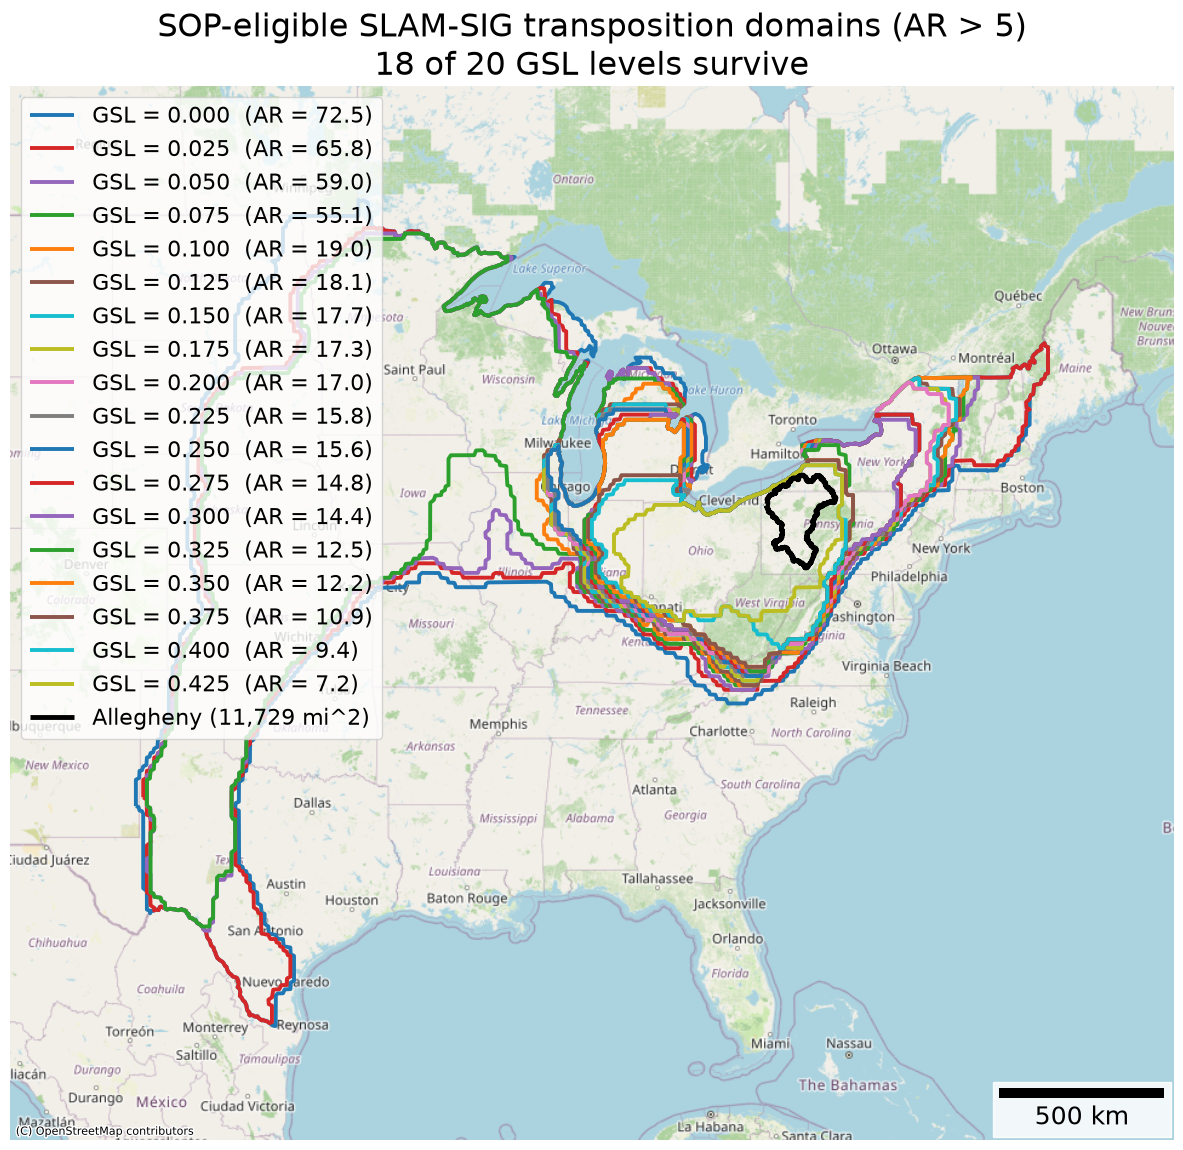

In [ ]:
# Distinctive non-black colors for the surviving TDs (watershed will be black solid).
TD_PALETTE = ['#1f77b4', '#d62728', '#9467bd', '#2ca02c', '#ff7f0e', '#8c564b',
              '#17becf', '#bcbd22', '#e377c2', '#7f7f7f']
gsl_color = {g: TD_PALETTE[i % len(TD_PALETTE)] for i, g in enumerate(sorted(survivors))}

fig, ax = plt.subplots(figsize=(14, 12))

# Largest TD first so smaller polygons sit on top.
for gsl in sorted(survivors, key=lambda g: candidate_tds[g].to_crs(EQUAL_AREA_CRS).area.sum(), reverse=True):
    gdf = candidate_tds[gsl].to_crs(PLOT_CRS)
    ar = ar_df.loc[ar_df['GSL'] == round(gsl, 3), 'Area Ratio (AR)'].iloc[0]
    gdf.boundary.plot(ax=ax, edgecolor=gsl_color[gsl], linewidth=2.8,
                      label=f'GSL = {gsl:.3f}  (AR = {ar:.1f})')

watershed.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor='black', linewidth=3.5, linestyle='-',
    label=f'{WATERSHED_NAME} ({BASIN_AREA_MI2:,.0f} mi^2)',
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
xpad = (xmax - xmin) * 0.08
ypad = (ymax - ymin) * 0.08
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

cx.add_basemap(ax, crs=PLOT_CRS, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()

center_lat_deg = watershed.to_crs(EQUAL_AREA_CRS).geometry.centroid.to_crs(GEOG_CRS).y.iloc[0]
ax.add_artist(ScaleBar(
    math.cos(math.radians(center_lat_deg)),
    units='m', location='lower right', box_alpha=0.85,
    rotation='horizontal-only',
    font_properties={'family': PLOT_FONT, 'size': PLOT_FONT_SIZE - 5},
))

ax.set_title(f'SOP-eligible SLAM-SIG transposition domains (AR > 5)\n{len(survivors)} of {len(GSL_VALUES)} GSL levels survive')
ax.legend(loc='upper left', frameon=True, fontsize=PLOT_FONT_SIZE - 7, ncol=1)
fig.tight_layout()
fig.savefig(OUT_DIR / 'stage1_survivors_map.png', dpi=180, bbox_inches='tight')
plt.show()

## Stage 2. Meteorological review on the SOP-eligible candidates

For each candidate that survived Stage 1, the meteorologist visually evaluates whether the
domain's climatology is consistent with the domain. The deliverable is a pixel-level
basin envelope coverage map: every PRISM pixel is scored 0 to 3 according to how many of the
three variables (precipitation, elevation, dewpoint) fall inside the basin's envelope.

Buffered envelope (5%): Instead of using the basin's raw min/max, the envelope is widened
by 5% of the basin's range on each side: `lo' = lo - 0.05 * (hi - lo)`, `hi' = hi + 0.05 * (hi - lo)`.
The basin's strict min/max are extremes drawn from a finite pixel sample and can be driven by
single PRISM cells (interpolation edges, isolated peaks, single snow stations). A modest
range-based buffer accommodates climatological variability beyond what was sampled and avoids
false negatives where a pixel just outside the basin's strict range is climatologically very
similar.

In [ ]:
def clip_to_boundary(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as r:
        bnd = boundary_gdf.to_crs(r.crs)
        out, _ = rio_mask(r, [mapping(g) for g in bnd.geometry], crop=True)
        arr = out[0].astype(float)
        if r.nodata is not None:
            arr = np.where(arr == r.nodata, np.nan, arr)
    return arr

ppt_basin = clip_to_boundary(PPT_PATH, watershed)
dem_basin = clip_to_boundary(DEM_PATH, watershed)
td_basin  = clip_to_boundary(TD_PATH,  watershed)

def buffered_range(arr, frac=0.05):
    lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
    pad = frac * (hi - lo)
    return lo - pad, hi + pad

ppt_lo, ppt_hi = buffered_range(ppt_basin, 0.05)
dem_lo, dem_hi = buffered_range(dem_basin, 0.05)
td_lo,  td_hi  = buffered_range(td_basin,  0.05)

print(f'{WATERSHED_NAME} buffered envelope (5% of range on each side):')
print(f'  Precip   : {ppt_lo:.1f} ... {ppt_hi:.1f} mm   ({ppt_lo/25.4:.1f} ... {ppt_hi/25.4:.1f} in)')
print(f'  Elevation: {dem_lo:.0f} ... {dem_hi:.0f} m    ({dem_lo*3.28084:.0f} ... {dem_hi*3.28084:.0f} ft)')
print(f'  Dewpoint : {td_lo:.2f} ... {td_hi:.2f} C    ({td_lo*9/5+32:.1f} ... {td_hi*9/5+32:.1f} F)')

Allegheny buffered envelope (5% of range on each side):
  Precip   : 1010.6 ... 1475.7 mm   (39.8 ... 58.1 in)
  Elevation: 248 ... 843 m    (815 ... 2765 ft)
  Dewpoint : 2.47 ... 5.76 C    (36.4 ... 42.4 F)


In [ ]:
with rasterio.open(PPT_PATH) as r:
    ppt_full = r.read(1).astype(float)
    if r.nodata is not None:
        ppt_full = np.where(ppt_full == r.nodata, np.nan, ppt_full)
    ref_transform, ref_crs, ref_shape = r.transform, r.crs, r.shape

with rasterio.open(TD_PATH) as r:
    td_full = r.read(1).astype(float)
    if r.nodata is not None:
        td_full = np.where(td_full == r.nodata, np.nan, td_full)

dem_full = np.full(ref_shape, np.nan, dtype=np.float32)
with rasterio.open(DEM_PATH) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=dem_full,
        src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
        dst_transform=ref_transform, dst_crs=ref_crs, dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )

in_ppt = (ppt_full >= ppt_lo) & (ppt_full <= ppt_hi)
in_dem = (dem_full >= dem_lo) & (dem_full <= dem_hi)
in_td  = (td_full  >= td_lo)  & (td_full  <= td_hi)
valid_mask = np.isfinite(ppt_full) & np.isfinite(dem_full) & np.isfinite(td_full)

score = in_ppt.astype(int) + in_dem.astype(int) + in_td.astype(int)
score = np.where(valid_mask, score.astype(float), np.nan)
print('Score range:', np.nanmin(score), '...', np.nanmax(score))

/tmp/ipykernel_17314/3520523468.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ppt_full = r.read(1).astype(float)
/tmp/ipykernel_17314/3520523468.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  td_full = r.read(1).astype(float)


Score range: 0.0 ... 3.0


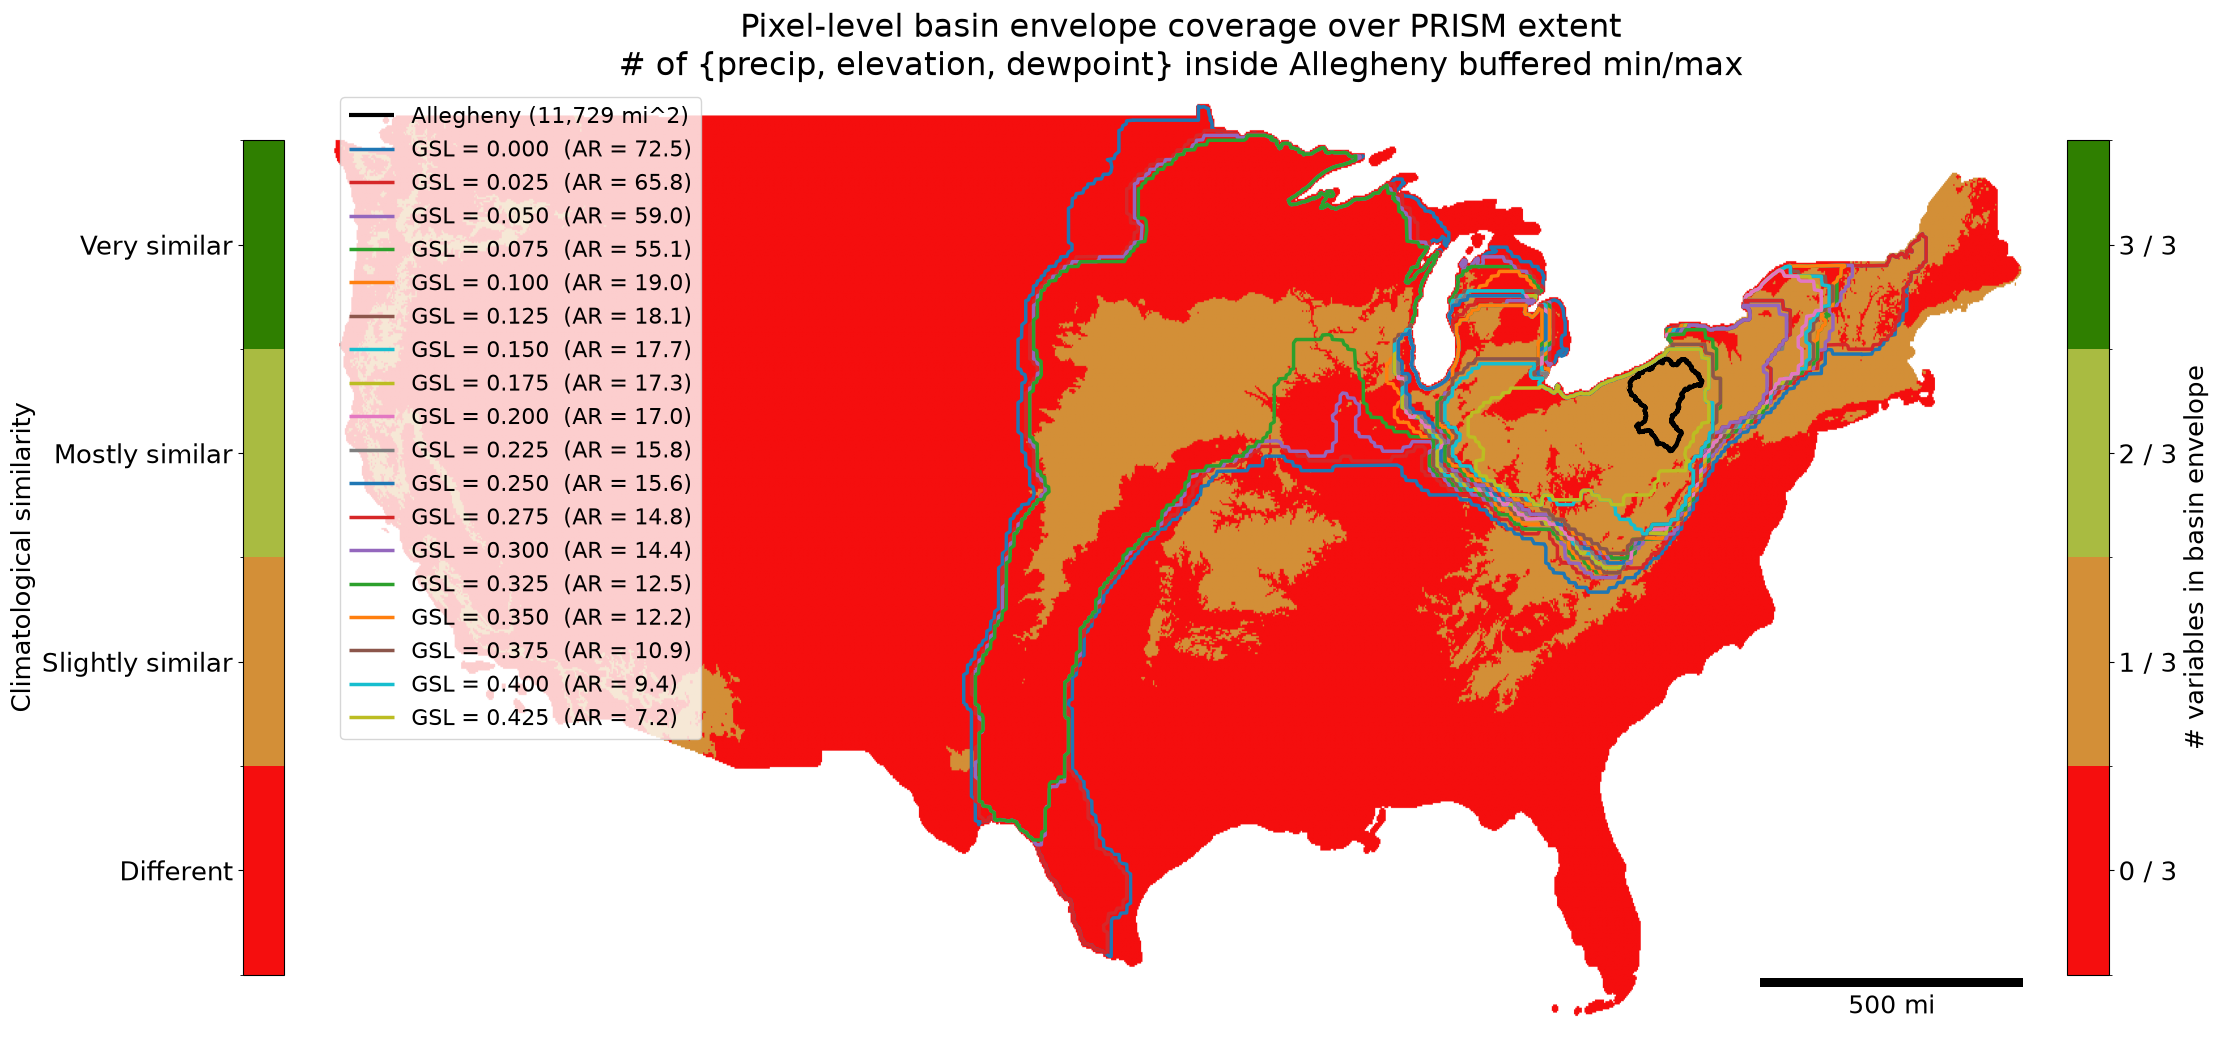

In [ ]:
discrete_cmap = mcolors.ListedColormap(['#f50e0e', '#d38f37', '#a9bb41', '#2f7f00'])
score_norm    = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], discrete_cmap.N)

minx, miny, maxx, maxy = array_bounds(ref_shape[0], ref_shape[1], ref_transform)
center_lat = (miny + maxy) / 2
cos_lat = math.cos(math.radians(center_lat))

fig, ax = plt.subplots(figsize=(22, 12), constrained_layout=True)
show(np.ma.masked_invalid(score), transform=ref_transform, ax=ax,
     cmap=discrete_cmap, norm=score_norm)

watershed.to_crs(ref_crs).boundary.plot(
    ax=ax, edgecolor='black', linestyle='-', linewidth=3.0,
    label=f'{WATERSHED_NAME} ({BASIN_AREA_MI2:,.0f} mi^2)',
)
for gsl in sorted(survivors):
    gdf = candidate_tds[gsl].to_crs(ref_crs)
    ar = ar_df.loc[ar_df['GSL'] == round(gsl, 3), 'Area Ratio (AR)'].iloc[0]
    gdf.boundary.plot(ax=ax, edgecolor=gsl_color[gsl], linewidth=2.5,
                      label=f'GSL = {gsl:.3f}  (AR = {ar:.1f})')

ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_aspect(1.0 / cos_lat)
ax.set_axis_off()

ax.set_title(
    f'Pixel-level basin envelope coverage over PRISM extent\n'
    f'# of {{precip, elevation, dewpoint}} inside {WATERSHED_NAME} buffered min/max'
)

PLAIN_LABELS = ['Different', 'Slightly similar', 'Mostly similar', 'Very similar']
cbar_left = fig.colorbar(ax.images[0], ax=ax, location='left',
                         ticks=[0, 1, 2, 3], shrink=0.7, pad=0.02)
cbar_left.ax.set_yticklabels(PLAIN_LABELS)
cbar_left.ax.tick_params(labelsize=PLOT_FONT_SIZE - 4)
cbar_left.set_label('Climatological similarity', fontsize=PLOT_FONT_SIZE - 4)

cbar_right = fig.colorbar(ax.images[0], ax=ax, location='right',
                          ticks=[0, 1, 2, 3], shrink=0.7, pad=0.02)
cbar_right.ax.set_yticklabels(['0 / 3', '1 / 3', '2 / 3', '3 / 3'])
cbar_right.ax.tick_params(labelsize=PLOT_FONT_SIZE - 4)
cbar_right.set_label('# variables in basin envelope', fontsize=PLOT_FONT_SIZE - 4)

ft_per_unit = 111_319.5 * cos_lat * 3.28084
ax.add_artist(ScaleBar(
    ft_per_unit, units='ft', dimension='imperial-length',
    fixed_value=500, fixed_units='mi',
    location='lower right', box_alpha=0.85, rotation='horizontal-only',
    font_properties={'family': PLOT_FONT, 'size': PLOT_FONT_SIZE - 5},
))
ax.legend(loc='upper left', fontsize=PLOT_FONT_SIZE - 7, ncol=1)
fig.savefig(OUT_DIR / 'stage2_envelope_coverage.png', dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
rows = []
for gsl in survivors:
    bnd = candidate_tds[gsl].to_crs(ref_crs)
    inside = geometry_mask([mapping(g) for g in bnd.geometry],
                           out_shape=ref_shape, transform=ref_transform, invert=True)
    sub = score[inside]
    sub = sub[np.isfinite(sub)]
    if sub.size == 0:
        continue
    pct3    = (sub == 3).mean() * 100
    pct_ge2 = (sub >= 2).mean() * 100
    rows.append({'GSL': round(gsl, 3),
                 'AR':  ar_df.loc[ar_df['GSL'] == round(gsl, 3), 'Area Ratio (AR)'].iloc[0],
                 'Pixels in TD': int(sub.size),
                 '% Very similar (3/3)':       pct3,
                 '% Mostly + Very (>=2/3)':    pct_ge2})

envelope_df = pd.DataFrame(rows).sort_values('% Very similar (3/3)', ascending=False).reset_index(drop=True)
envelope_df.to_csv(OUT_DIR / 'stage2_envelope_match.csv', index=False)

(envelope_df.style
    .format({'GSL':                       '{:.3f}',
             'AR':                        '{:.2f}',
             'Pixels in TD':              '{:,d}',
             '% Very similar (3/3)':      '{:.1f}',
             '% Mostly + Very (>=2/3)':   '{:.1f}'})
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#37474f'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                     ('padding', '4px 10px')]},
    ]))

GSL,AR,Pixels in TD,% Very similar (3/3),% Mostly + Very (>=2/3)
0.425,7.24,"11,586",52.3,84.9
0.400,9.45,"15,060",45.4,84.2
0.375,10.85,"17,270",41.9,84.5
0.300,14.41,"23,134",37.2,80.7
0.350,12.20,"19,519",37.1,80.4
0.275,14.80,"23,763",36.6,80.2
0.325,12.52,"20,036",36.4,79.9
0.250,15.57,"25,001",34.9,78.4
0.225,15.78,"25,347",34.5,78.0
0.200,16.97,"27,296",32.7,78.1


### Tcap, the SST-simulation return-period ceiling

After stochastic transposition the post-simulation return-period ceiling is set by the AORC
record length and the basin-to-domain area ratio:

$$\text{AEP}_{\min} = \frac{p_{\text{hit}}}{Y}, \qquad T_{\text{cap}} = \frac{Y}{p_{\text{hit}}} = Y \cdot \text{AR}$$

where Y is the AORC catalog length in years (here Y = 46, covering 1980 to 2025 inclusive),
p_hit = A_basin / A_TD, and AR = A_TD / A_basin = 1 / p_hit.

In [ ]:
tcap_rows = []
for _, r in envelope_df.iterrows():
    tcap_rows.append({
        'GSL':                  r['GSL'],
        'AR':                   r['AR'],
        'Y (yr)':               AORC_YEARS,
        'Tcap = Y * AR (yr)':   AORC_YEARS * r['AR'],
        '% Very similar (3/3)': r['% Very similar (3/3)'],
    })
tcap_df = pd.DataFrame(tcap_rows)
tcap_df.to_csv(OUT_DIR / 'stage2_tcap.csv', index=False)

(tcap_df.style
    .format({'GSL':                  '{:.3f}',
             'AR':                   '{:.2f}',
             'Y (yr)':               '{:d}',
             'Tcap = Y * AR (yr)':   '{:,.0f}',
             '% Very similar (3/3)': '{:.1f}'})
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#37474f'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                     ('padding', '4px 10px')]},
    ]))

GSL,AR,Y (yr),Tcap = Y * AR (yr),% Very similar (3/3)
0.425,7.24,46,333,52.3
0.400,9.45,46,435,45.4
0.375,10.85,46,499,41.9
0.300,14.41,46,663,37.2
0.350,12.20,46,561,37.1
0.275,14.80,46,681,36.6
0.325,12.52,46,576,36.4
0.250,15.57,46,716,34.9
0.225,15.78,46,726,34.5
0.200,16.97,46,781,32.7


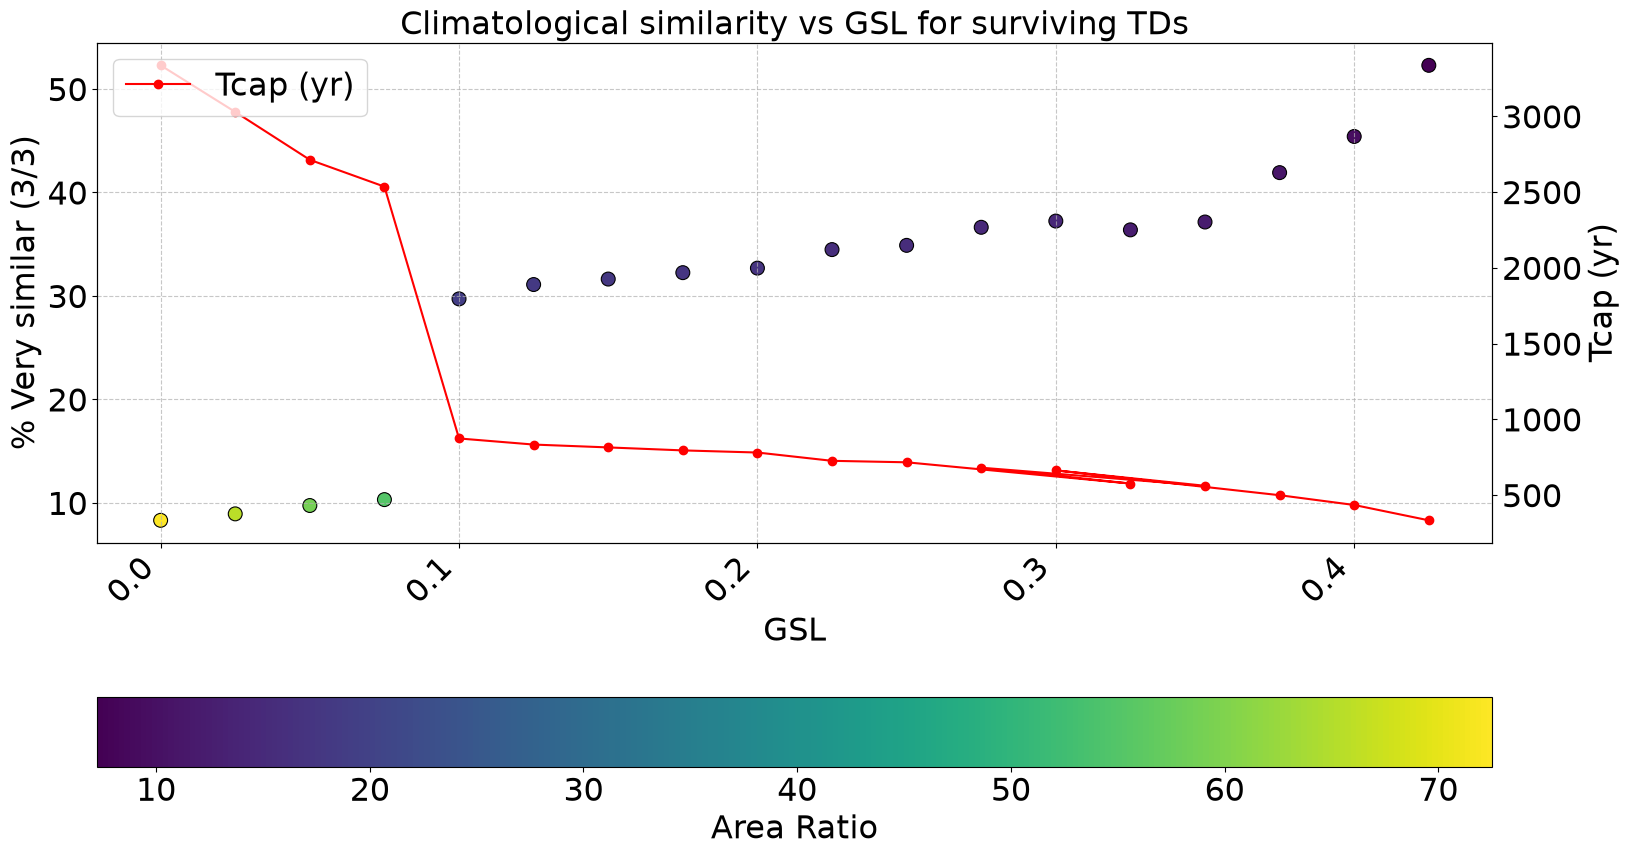

In [ ]:
# plot GSL vs % Very similar (3/3) for the surviving TDs
fig, ax = plt.subplots(figsize=(18, 10))
# color points by AR value, with a colorbar
norm = mpl.colors.Normalize(vmin=tcap_df['AR'].min(), vmax=tcap_df['AR'].max())
cmap = mpl.cm.viridis
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
ax.scatter(tcap_df['GSL'], tcap_df['% Very similar (3/3)'], color=sm.to_rgba(tcap_df['AR']), s=100, edgecolor='black', linewidth=0.8)
ax.set_xlabel('GSL')
ax.set_ylabel('% Very similar (3/3)')
ax.set_title('Climatological similarity vs GSL for surviving TDs')
ax.grid(True, linestyle='--', alpha=0.7)
# add delta Tcap as a secondary series
tcap_df['Delta Tcap'] = tcap_df['Tcap = Y * AR (yr)'].diff().fillna(0)
ax2 = ax.twinx()
ax2.plot(tcap_df['GSL'], tcap_df['Tcap = Y * AR (yr)'], color='red', marker='o', linestyle='-', label='Tcap (yr)')
# set log scale for secondary y-axis, but handle zero/negative values by setting them to a small positive value for plotting
# ax2.set_yscale('symlog', linthresh=1)
ax2.set_ylabel('Tcap (yr)')
ax2.legend(loc='upper left')
# move cbar to horizontal below the plot
fig.colorbar(sm, ax=ax, label='Area Ratio', orientation='horizontal', pad=0.2)
# rotate x-ticks for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.savefig(OUT_DIR / 'stage2_gsl_vs_similarity.png', dpi=180, bbox_inches='tight')
plt.show()

### Example Meteorologist's interpretation and selection: Upper Tennessee

Two GSL levels survived the Stage 1 hard filter: GSL = 0.000 (AR = 6.5) and GSL = 0.025
(AR = 5.4). The Stage 2 envelope coverage table shows the two are climatologically very similar:
GSL = 0.025 has 83.3% of its pixels matching all three basin variables; GSL = 0.000 has 79.3%.
Both sit around 95% to 96% at the 2/3 (mostly + very similar) threshold. Visually on the
envelope coverage map, the two polygons enclose substantially the same green region around
the southern Appalachians. The only difference is a thin border ring that GSL = 0.000 picks
up beyond GSL = 0.025.

Tcap differs more meaningfully: GSL = 0.000 results in Tcap = 46 * 6.52 = 300 yr and
GSL = 0.025 yields Tcap = 46 * 5.43 = 250 yr. Both are below the 500 to 1,000 yr target set for HUC-4 studies, but GSL = 0.000 is closer to it by 50 yr of effective record.
Since the additional area in GSL = 0.000 does not introduce a meaningfully different
climatology (the envelope coverage barely changes), there is no climatological cost to taking
the larger Tcap.

**Selection: GSL = 0.000 (AR = 6.5, Tcap = 300 yr).** This is the larger of the two
SOP-eligible candidates. It has the highest available Tcap and the meteorological envelope
characterization is essentially indistinguishable from the smaller candidate. Stage 3 below
uses GSL = 0.000 as the selected polygon.

In [ ]:
selected_gsl = 0.100
selected_ar  = float(ar_df.loc[ar_df['GSL'] == round(selected_gsl, 3), 'Area Ratio (AR)'].iloc[0])
selected_tcap = AORC_YEARS * selected_ar
print(f'Selected: GSL = {selected_gsl:.3f}  |  AR = {selected_ar:.2f}  |  Tcap = {selected_tcap:.0f} yr')

Selected: GSL = 0.100  |  AR = 18.99  |  Tcap = 874 yr


## Stage 3. Statistical QA on the selected polygon

These tables go into the documentation. They do not change the selection.

In [ ]:
selected_td = candidate_tds[selected_gsl]
domains_for_qa = {
    WATERSHED_NAME:                   watershed,
    f'SLAM-SIG GSL = {selected_gsl:.3f}': selected_td,
}

stats_rows = []
for name, gdf in domains_for_qa.items():
    ppt_in = clip_to_boundary(PPT_PATH, gdf) / 25.4
    dem_ft = clip_to_boundary(DEM_PATH, gdf) * 3.28084
    td_f   = clip_to_boundary(TD_PATH,  gdf) * 9/5 + 32
    stats_rows.append({
        'Domain': name,
        'Precip Mean (in)': np.nanmean(ppt_in),
        'Precip Min (in)':  np.nanmin(ppt_in),
        'Precip Max (in)':  np.nanmax(ppt_in),
        'Elev Mean (ft)':   np.nanmean(dem_ft),
        'Elev Min (ft)':    np.nanmin(dem_ft),
        'Elev Max (ft)':    np.nanmax(dem_ft),
        'Td Mean (F)':      np.nanmean(td_f),
        'Td Min (F)':       np.nanmin(td_f),
        'Td Max (F)':       np.nanmax(td_f),
    })

stats_table = pd.DataFrame(stats_rows).set_index('Domain')
stats_table.to_csv(OUT_DIR / 'stage3_climate_stats.csv')

(stats_table.style
    .format({c: '{:.1f}' for c in stats_table.columns})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#37474f'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'right'),
                                     ('padding', '4px 10px')]},
    ]))

,Precip Mean (in),Precip Min (in),Precip Max (in),Elev Mean (ft),Elev Min (ft),Elev Max (ft),Td Mean (F),Td Min (F),Td Max (F)
Domain,,,,,,,,,
Allegheny,46.5,40.6,57.3,1596.9,903.3,2676.6,38.9,36.7,42.1
SLAM-SIG GSL = 0.100,42.6,29.8,73.9,1159.9,95.1,4302.4,40.4,29.1,46.2


In [ ]:
domain_distributions = {
    'Precipitation (in)': {},
    'Elevation (ft)':     {},
    'Dewpoint (F)':       {},
}
for name, gdf in domains_for_qa.items():
    ppt_in = clip_to_boundary(PPT_PATH, gdf) / 25.4
    dem_ft = clip_to_boundary(DEM_PATH, gdf) * 3.28084
    td_f   = clip_to_boundary(TD_PATH,  gdf) * 9/5 + 32
    for var, arr in [('Precipitation (in)', ppt_in),
                     ('Elevation (ft)',     dem_ft),
                     ('Dewpoint (F)',       td_f)]:
        flat = arr.flatten()
        domain_distributions[var][name] = flat[np.isfinite(flat)]

SAMPLE_SIZE = 50_000
rng = np.random.default_rng(seed=42)
names = list(domains_for_qa.keys())
a_name, b_name = names[0], names[1]

rows = []
for var, dists in domain_distributions.items():
    A, B = dists[a_name], dists[b_name]
    if len(A) > SAMPLE_SIZE: A = rng.choice(A, SAMPLE_SIZE, replace=False)
    if len(B) > SAMPLE_SIZE: B = rng.choice(B, SAMPLE_SIZE, replace=False)
    ks = ks_2samp(A, B)
    wd = wasserstein_distance(A, B)
    med_diff = np.median(A) - np.median(B)
    p95_diff = np.percentile(A, 95) - np.percentile(B, 95)
    rows.append({
        'Variable':       var,
        'Comparison':     f'{a_name} vs. {b_name}',
        'KS Statistic':   ks.statistic,
        'Wasserstein':    wd,
        'Median Diff':    med_diff,
        '95th Pct Diff':  p95_diff,
    })

dist_table = pd.DataFrame(rows).set_index(['Variable', 'Comparison'])
dist_table.to_csv(OUT_DIR / 'stage3_distributional_comparison.csv')

(dist_table.style
    .format({'KS Statistic':  '{:.4f}',
             'Wasserstein':   '{:.3f}',
             'Median Diff':   '{:.3f}',
             '95th Pct Diff': '{:.3f}'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#37474f'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('text-align', 'right'),
                                     ('padding', '4px 10px')]},
    ]))

,,KS Statistic,Wasserstein,Median Diff,95th Pct Diff
Variable,Comparison,,,,
Precipitation (in),Allegheny vs. SLAM-SIG GSL = 0.100,0.5025,4.286,4.305,-1.467
Elevation (ft),Allegheny vs. SLAM-SIG GSL = 0.100,0.5877,489.007,578.774,-208.087
Dewpoint (F),Allegheny vs. SLAM-SIG GSL = 0.100,0.4150,1.926,-1.763,-3.812


### Example Summary of findings: Upper Tennessee

- Selected domain for Upper Tennessee: SLAM-SIG at GSL = 0.000, AR = 6.52, Tcap = 300 yr.
- Stage 1 eliminated 18 of 20 candidate GSLs on the SOP requirement that AR > 5; only
  GSL = 0.000 and GSL = 0.025 remained.
- Stage 2 envelope coverage shows the two survivors are climatologically near-identical inside
  their footprints (around 79% to 83% of pixels match all three basin variables under a 5%
  range buffer and both sit near 95% to 96% at the 2/3 threshold). The larger polygon does not
  introduce a meaningfully different climatology.
- Tcap distinguishes the survivors: GSL = 0.000 carries 50 yr more effective return-period
  reach than GSL = 0.025 at no climatological cost.
- Stage 3 statistics describe the chosen polygon's climatology relative to the basin. The KS
  and Wasserstein values are reported as descriptive distance metrics. They were not used to
  drive the selection.

# Save the Selected Domain

In [ ]:
selected_td.to_file(OUT_DIR / f'SEL_SLAM-SIG-GSL{selected_gsl:.3f}_EPSG5070.geojson', driver='GeoJSON')

## PRISM raster maps with domain boundaries (CONUS extent)

Each of the three PRISM 30-year normals (precipitation, elevation, dewpoint) is plotted at
its full CONUS extent, with the domain watershed (black) and the selected SLAM-SIG
domain at GSL = 0.000 (blue) overlaid. Color scale uses Jenks Natural Breaks (k = 10);
dual-unit colorbars (left = native, right = customary).

/tmp/ipykernel_17314/303806485.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = r.read(1).astype(float)


  Jenks input: 420,200 finite pixels  (min=46.3, max=5603)


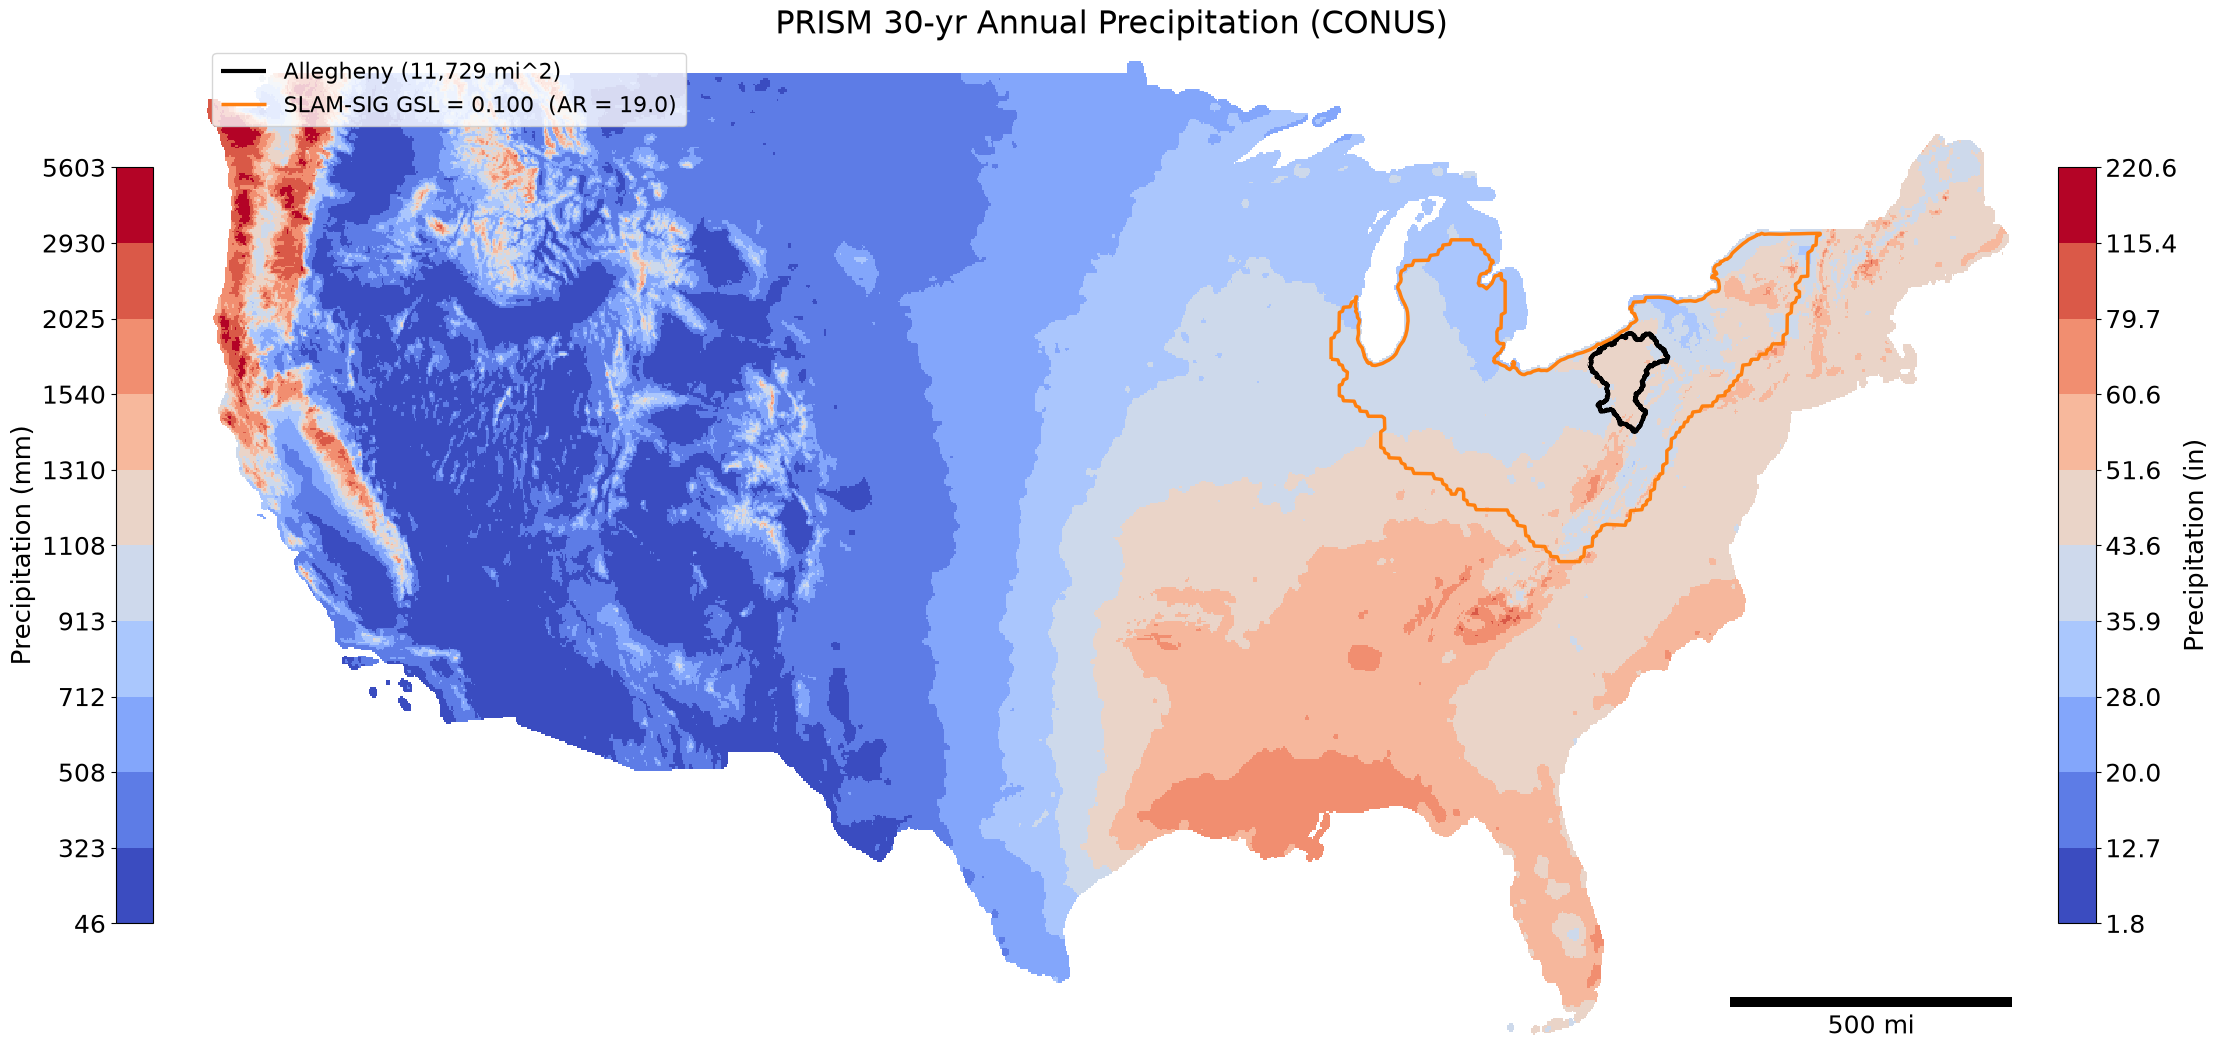

/tmp/ipykernel_17314/303806485.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = r.read(1).astype(float)


  Jenks input: 420,186 finite pixels  (min=-78.81, max=3900)


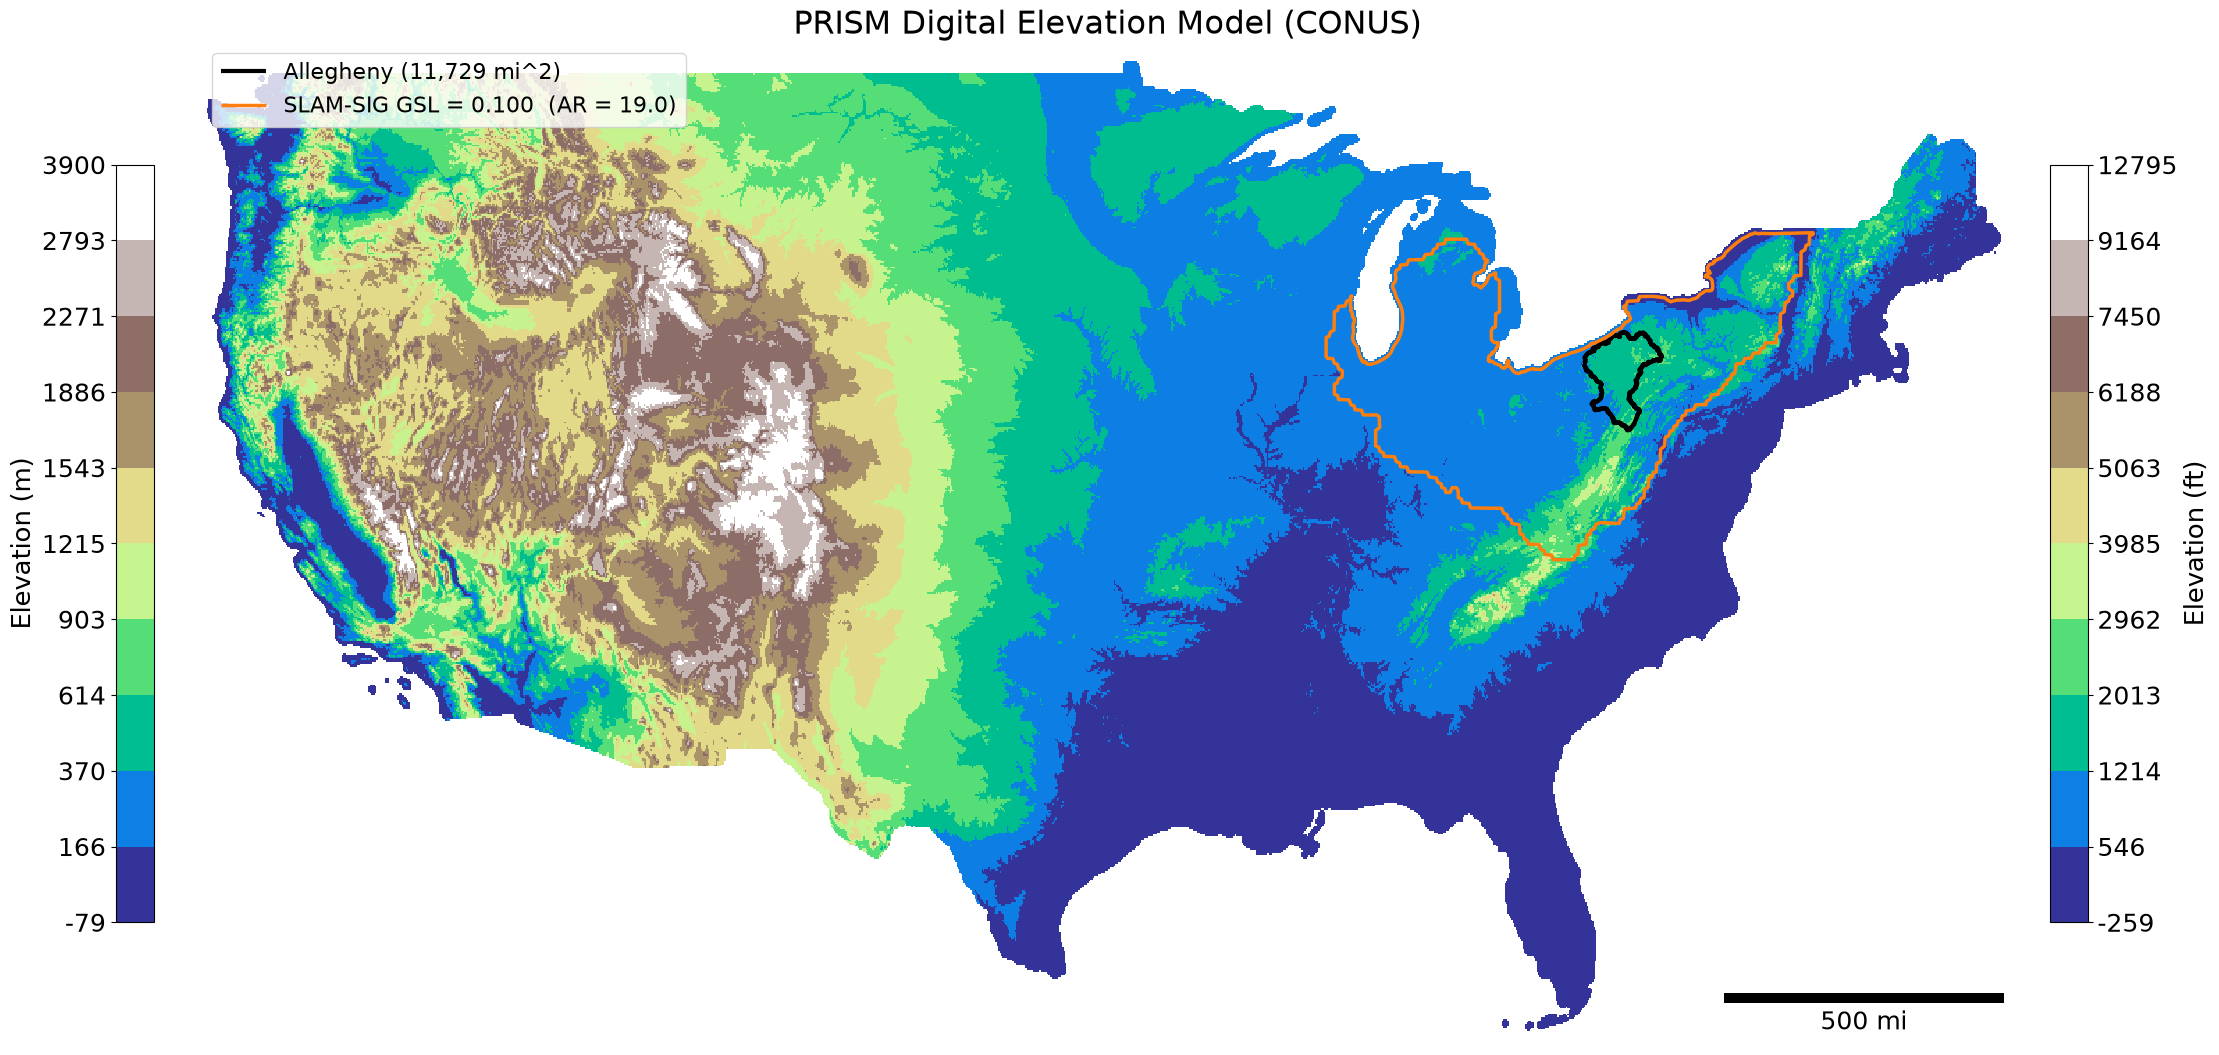

/tmp/ipykernel_17314/303806485.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = r.read(1).astype(float)


  Jenks input: 420,200 finite pixels  (min=-13.85, max=20.82)


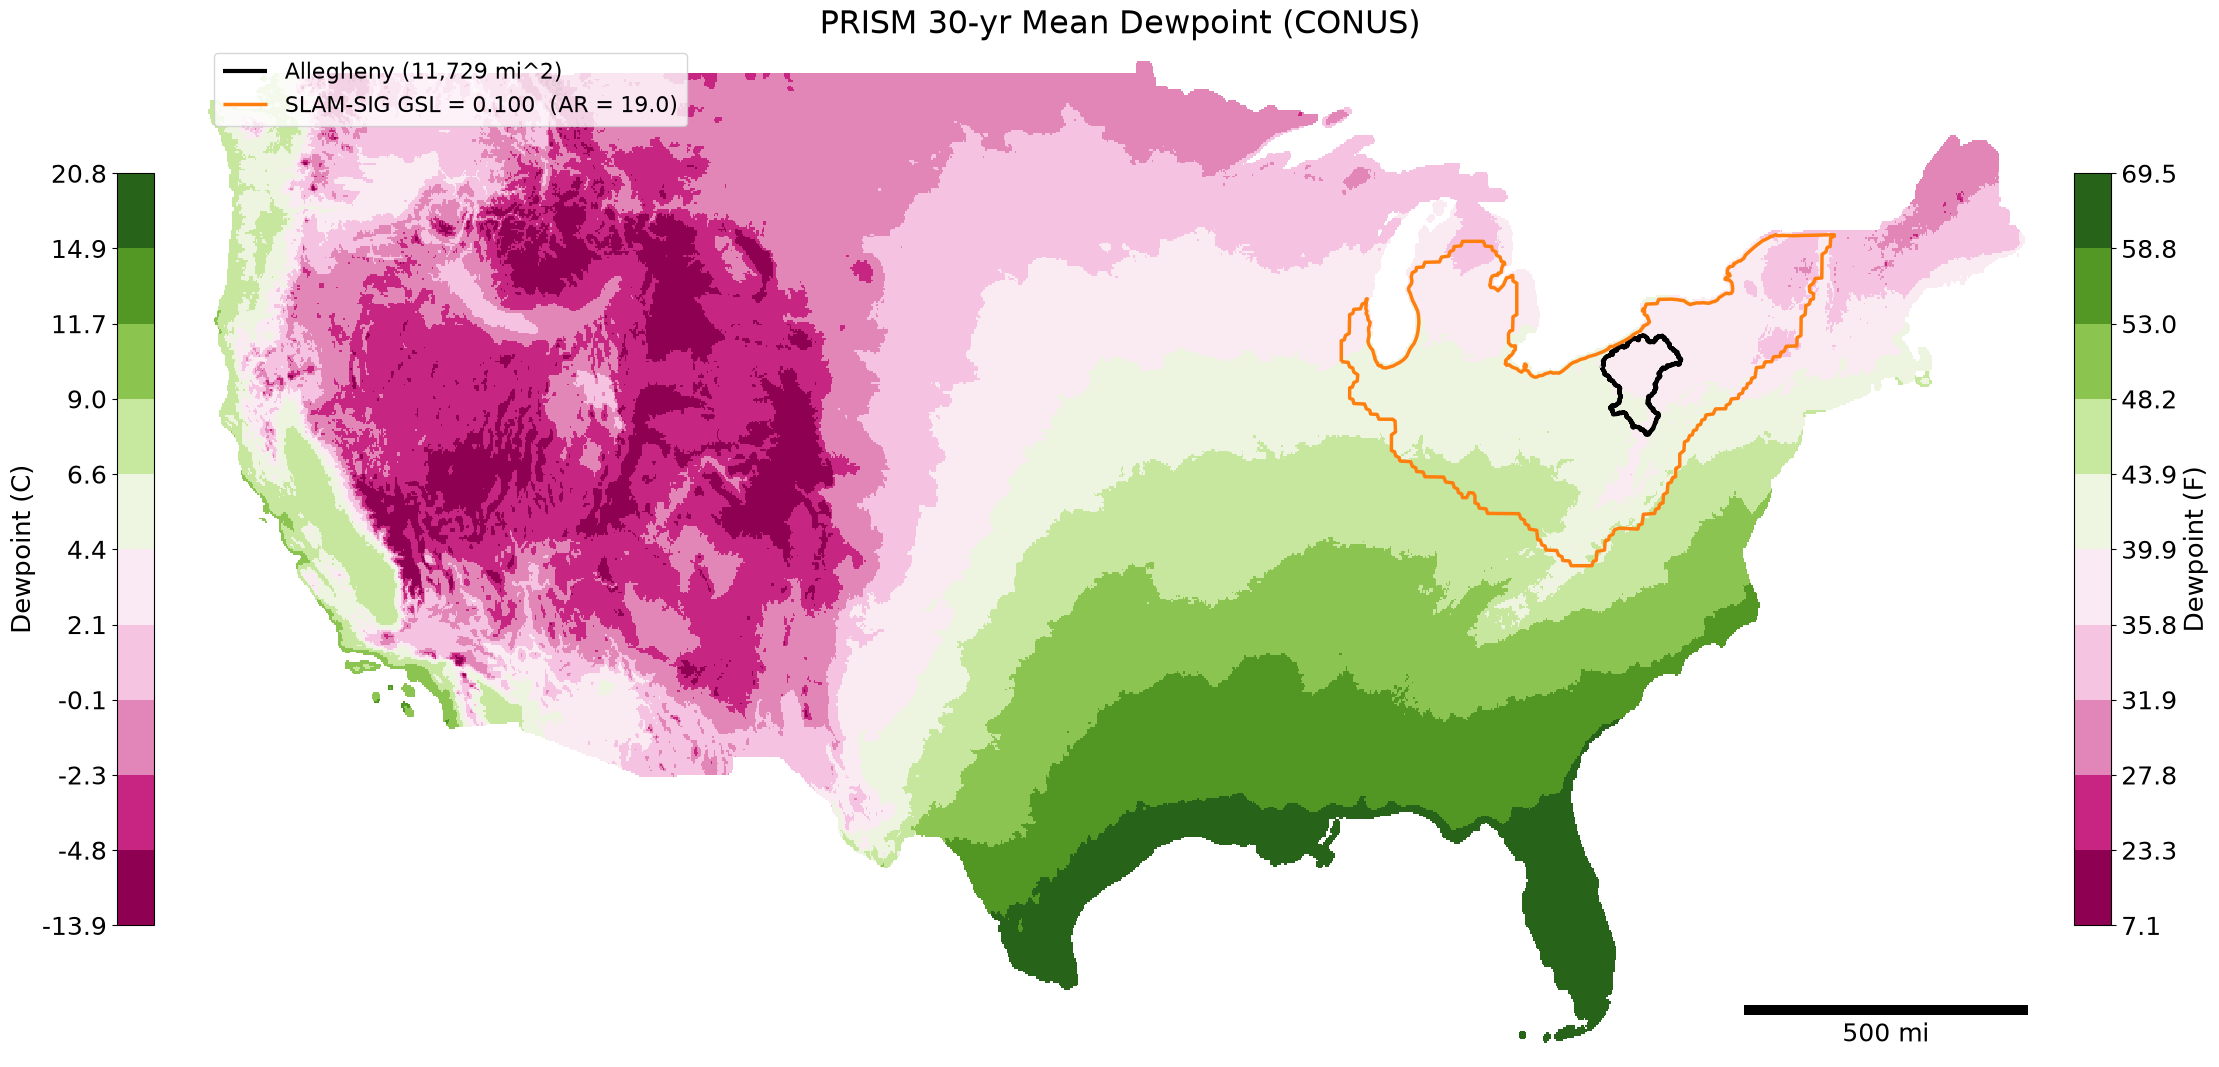

In [ ]:
def plot_prism_conus(raster_path, *, cmap, primary_label, primary_fmt,
                     secondary_fn, secondary_label, secondary_fmt,
                     title, out_name, jenks_k=10):
    with rasterio.open(raster_path) as r:
        data = r.read(1).astype(float)
        if r.nodata is not None:
            data = np.where(data == r.nodata, np.nan, data)
        transform = r.transform
        bounds = r.bounds
        crs_r = r.crs

    flat = data[np.isfinite(data)].ravel()
    print(f'  Jenks input: {flat.size:,} finite pixels  '
          f'(min={flat.min():.4g}, max={flat.max():.4g})')
    breaks = mapclassify.NaturalBreaks(flat, k=jenks_k).bins.astype(float)
    edges = np.unique(np.concatenate(([float(flat.min())], breaks)))
    cmap_d = mpl.colormaps[cmap].resampled(len(edges) - 1)
    norm = BoundaryNorm(edges, cmap_d.N)

    minx, miny, maxx, maxy = bounds
    center_lat = (miny + maxy) / 2
    cos_lat = math.cos(math.radians(center_lat))

    fig, ax = plt.subplots(figsize=(22, 11), constrained_layout=True)
    img = ax.imshow(
        np.ma.masked_invalid(data),
        extent=[minx, maxx, miny, maxy],
        origin='upper', cmap=cmap_d, norm=norm,
        interpolation='nearest',
    )

    watershed.to_crs(crs_r).boundary.plot(
        ax=ax, edgecolor='black', linestyle='-', linewidth=3.0,
        label=f'{WATERSHED_NAME} ({BASIN_AREA_MI2:,.0f} mi^2)',
    )
    selected_td.to_crs(crs_r).boundary.plot(
        ax=ax, edgecolor=gsl_color[selected_gsl], linestyle='-', linewidth=2.5,
        label=f'SLAM-SIG GSL = {selected_gsl:.3f}  (AR = {selected_ar:.1f})',
    )

    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_aspect(1.0 / cos_lat)
    ax.set_axis_off()
    ax.set_title(title)

    cb_left = fig.colorbar(img, ax=ax, location='left',
                           ticks=edges, shrink=0.7, pad=0.02)
    cb_left.set_ticks(edges)
    cb_left.set_ticklabels([primary_fmt.format(e) for e in edges])
    cb_left.ax.tick_params(labelsize=PLOT_FONT_SIZE - 5)
    cb_left.ax.minorticks_off()
    cb_left.set_label(primary_label, fontsize=PLOT_FONT_SIZE - 4)

    cb_right = fig.colorbar(img, ax=ax, location='right',
                            ticks=edges, shrink=0.7, pad=0.02)
    cb_right.set_ticks(edges)
    cb_right.set_ticklabels([secondary_fmt.format(secondary_fn(e)) for e in edges])
    cb_right.ax.tick_params(labelsize=PLOT_FONT_SIZE - 5)
    cb_right.ax.minorticks_off()
    cb_right.set_label(secondary_label, fontsize=PLOT_FONT_SIZE - 4)

    ft_per_unit = 111_319.5 * cos_lat * 3.28084
    ax.add_artist(ScaleBar(
        ft_per_unit, units='ft', dimension='imperial-length',
        fixed_value=500, fixed_units='mi',
        location='lower right', box_alpha=0.85, rotation='horizontal-only',
        font_properties={'family': PLOT_FONT, 'size': PLOT_FONT_SIZE - 5},
    ))
    ax.legend(loc='upper left', fontsize=PLOT_FONT_SIZE - 7)
    fig.savefig(OUT_DIR / out_name, dpi=180, bbox_inches='tight')
    plt.show()


plot_prism_conus(
    PPT_PATH,
    cmap='coolwarm',
    primary_label='Precipitation (mm)',
    primary_fmt='{:.0f}',
    secondary_fn=lambda v: v / 25.4,
    secondary_label='Precipitation (in)',
    secondary_fmt='{:.1f}',
    title='PRISM 30-yr Annual Precipitation (CONUS)',
    out_name='conus_prism_precip.png',
)

plot_prism_conus(
    DEM_PATH,
    cmap='terrain',
    primary_label='Elevation (m)',
    primary_fmt='{:.0f}',
    secondary_fn=lambda v: v * 3.28084,
    secondary_label='Elevation (ft)',
    secondary_fmt='{:.0f}',
    title='PRISM Digital Elevation Model (CONUS)',
    out_name='conus_prism_dem.png',
)

plot_prism_conus(
    TD_PATH,
    cmap='PiYG',
    primary_label='Dewpoint (C)',
    primary_fmt='{:.1f}',
    secondary_fn=lambda v: v * 9/5 + 32,
    secondary_label='Dewpoint (F)',
    secondary_fmt='{:.1f}',
    title='PRISM 30-yr Mean Dewpoint (CONUS)',
    out_name='conus_prism_dewpoint.png',
)
